In [1]:
# ═══════════════════════════════════════════════════════════════════════════════
# DIFMAP PYTHON WRAPPER - DÉMONSTRATION COMPLÈTE
# ═══════════════════════════════════════════════════════════════════════════════
# Ce notebook démontre les capacités du wrapper Python pour Difmap :
#   • Chargement et sélection des données UV
#   • Imagerie (Dirty Map, Clean Map, Residual Map)
#   • Contrôle complet des paramètres CLEAN (niter, gain, cutoff)
#   • Gestion des fenêtres CLEAN (addwin, peakwin, delwin)
#   • Auto-calibration (selfcal)
#   • Extraction des composantes du modèle
# ═══════════════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import numpy as np
from difmap_wrapper import DifmapSession

# ── PARAMÈTRES DE LA DÉMO ──────────────────────────────────────────────────────
DATA_PATH      = "tests/test_data/0003-066_X.SPLIT.1"  # Fichier FITS-UV
REQUESTED_POL  = "RR"                                   # Polarisation
REQUESTED_IFS  = (1, 0)                                 # (premier, dernier) ; 0 = tous

# Imagerie
MAP_SIZE       = 512    # Grille en pixels (puissance de 2)
CELL_SIZE_MAS  = 0.1    # Taille pixel en milliarcsecondes

# CLEAN - Paramètres pour la démo
CLEAN_NITER    = -500   # Négatif = arrêt au 1er composant négatif
CLEAN_GAIN     = 0.1    # Gain de boucle (typique: 0.05-0.2)
CLEAN_CUTOFF   = 0.003  # Seuil de flux (Jy/beam) - arrêt automatique

# ── FONCTIONS UTILITAIRES ──────────────────────────────────────────────────────
def format_if_range(ifs):
    """Convertit (1, 2) → '1..2', (1, 0) → 'tous'."""
    a, b = ifs
    return "tous" if b == 0 else f"{a}..{b}"

def unique_ifs(data):
    """Retourne la liste triée des IFs présents."""
    return sorted(set(int(x) for x in np.unique(data["if_no"])))

def print_beam_info(session):
    """Affiche les paramètres du faisceau synthétique."""
    beam = session.imager._native.get_beam_info()
    print(f"Beam: BMAJ={beam['BMAJ']:.3f} mas, BMIN={beam['BMIN']:.3f} mas, BPA={beam['BPA']:.1f}°")
    print(f"RMS: {beam['RMS']*1000:.3f} mJy/beam")

# ## 1. Chargement des données UV

In [2]:
# Création de la session Difmap (singleton)
session = DifmapSession()
session.observe(DATA_PATH)
selected_pol = session.obs.select(pol=REQUESTED_POL, ifs=REQUESTED_IFS)

print(f" Source      : {session.obs.source:<22}")
print(f" Polarisation: {selected_pol:<22}")
print(f" IFs         : {format_if_range(REQUESTED_IFS):<22}")


Reading UV FITS file: tests/test_data/0003-066_X.SPLIT.1
AN table 1: 110 integrations on 120 of 120 possible baselines.
AN table 2: 34 integrations on 120 of 120 possible baselines.
AN table 3: 136 integrations on 120 of 120 possible baselines.
AN table 4: 68 integrations on 120 of 120 possible baselines.
AN table 5: 27 integrations on 120 of 120 possible baselines.
AN table 6: Unused.
AN table 7: Unused.
Apparent sampling: 0.0726222 visibilities/baseline/integration-bin.
*** This seems a bit low - see "help observe" on the binwid argument.
Found source: 0003-066

There are 4 IFs, and a total of 4 channels:

 IF  Channel    Frequency  Freq offset  Number of   Overall IF
      origin    at origin  per channel   channels    bandwidth
 ------------------------------------------------------------- (Hz)
 01        1  8.37372e+09      1.6e+07          1      1.6e+07
 02        2  8.45372e+09      1.6e+07          1      1.6e+07
 03        3  8.81372e+09      1.6e+07          1      1.6e+07
 

# ## 2. Inspection des visibilités

In [3]:
data = session.obs.get_data()

print(f"Visibilités chargées : {len(data['u']):,}")
print(f"IFs présents         : {unique_ifs(data)}")
print(f"Amplitude moyenne    : {data['amp'].mean():.4f} Jy")
print(f"Amplitude max        : {data['amp'].max():.4f} Jy")

Visibilités chargées : 13,072
IFs présents         : [1, 2, 3, 4]
Amplitude moyenne    : 2.8165 Jy
Amplitude max        : 4.3546 Jy


# ## 3. Couverture UV

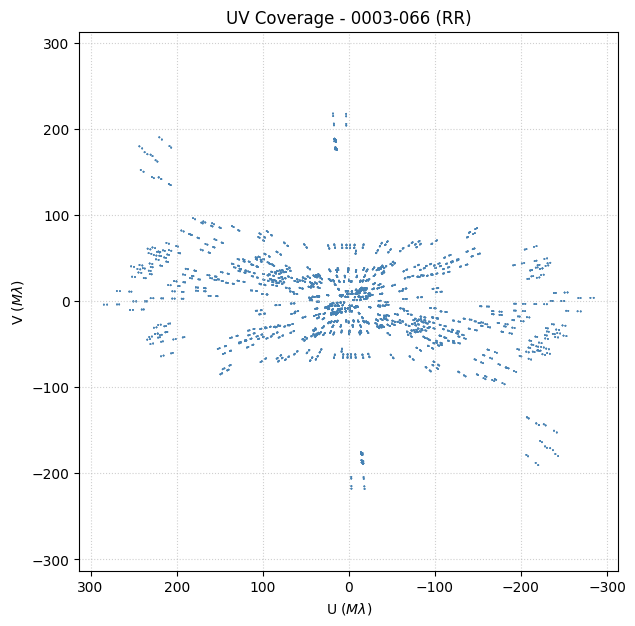

In [4]:
session.vis.uvplot(
    figsize=(7, 7),
    color="steelblue",
    s=1.5,
    alpha=0.35,
    title=f"UV Coverage - {session.obs.source} ({selected_pol})"
)
plt.show()

# ## 4. Radial Plot (Amplitude vs baseline)

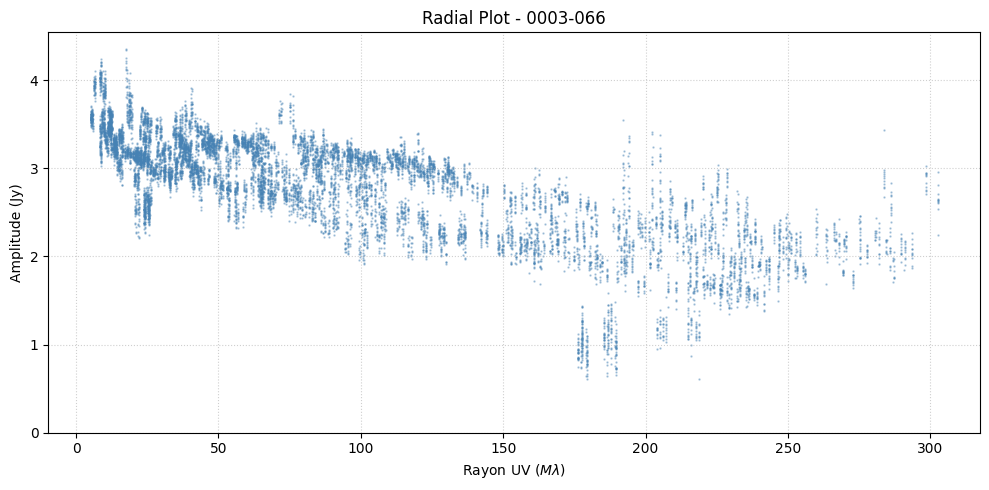

In [5]:
u, v = data['u'], data['v']
amp = data['amp']
uv_r = np.sqrt(u**2 + v**2) / 1e6  # Mλ

fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(uv_r, amp, s=0.5, color='steelblue', alpha=0.4)
ax.set_xlabel(r"Rayon UV ($M\lambda$)")
ax.set_ylabel("Amplitude (Jy)")
ax.set_ylim(bottom=0)
ax.set_title(f"Radial Plot - {session.obs.source}")
ax.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

# ## 5. Dirty Map (sans déconvolution)

Grille: 512×512 pixels, 0.1 mas/pixel
Beam: BMAJ=0.000 mas, BMIN=0.000 mas, BPA=0.0°
RMS: 121.197 mJy/beam
Inverting map and beam 
Estimated beam: bmin=0.5457 mas, bmaj=1.323 mas, bpa=-9.027 degrees
Estimated noise=1.57154 mJy/beam.


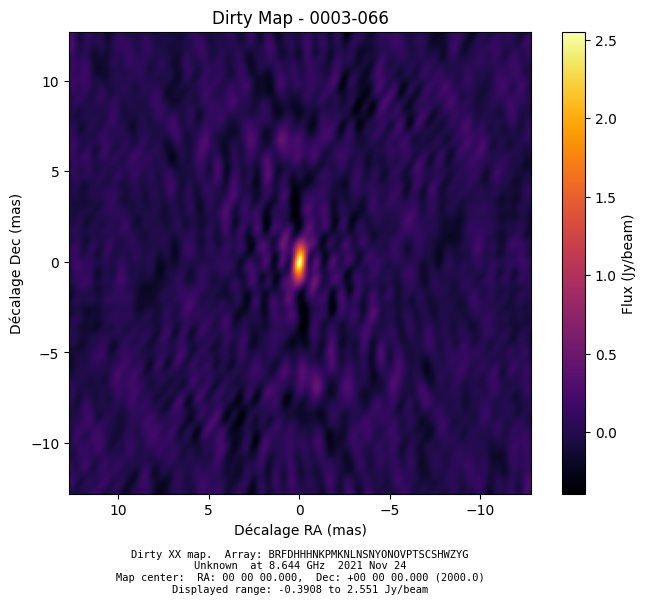

In [6]:
# Définition de la grille d'imagerie
session.imager.mapsize(MAP_SIZE, CELL_SIZE_MAS)
print(f"Grille: {MAP_SIZE}×{MAP_SIZE} pixels, {CELL_SIZE_MAS} mas/pixel")

# Calcul de la Dirty Map (FFT inverse)
session.imager.invert()
print_beam_info(session)

# Affichage SANS contours (conformément à Difmap)
# Important: ne pas forcer xlim/ylim plus grands que l'extent de l'image
# sinon ça crée une marge (cadre blanc) dans la figure.
session.vis.mapplot(
    title=f"Dirty Map - {session.obs.source}",
    cmap="inferno",
)
plt.show()

# ## 6. Fenêtres CLEAN (Clean Windows)

In [7]:
# ═══════════════════════════════════════════════════════════════════════════════
# DÉMONSTRATION DES FENÊTRES CLEAN
# ═══════════════════════════════════════════════════════════════════════════════

# Méthode 1: Fenêtre automatique autour du pic de flux
# size=1.0 (défaut) = 1× le FWHM du beam synthétique — identique au GUI
session.imager.peakwin()  # 1× FWHM autour du pic positif
print("✓ peakwin(): fenêtre de 1× FWHM ajoutée autour du pic positif")

# Méthode 2: Fenêtre manuelle (pour sources étendues ou sous-structures)
# Format: addwin(xa, xb, ya, yb) en mas depuis le centre
# Note: 10×10 mas est volontairement large pour la démo ;
#       pour une source compacte, préférer ~2× FWHM (ici ~2.4 × 5.2 mas)
session.imager.addwin(-5, 5, -5, 5)
print("✓ addwin(-5, 5, -5, 5): fenêtre manuelle de 10×10 mas ajoutée")

# Lister les fenêtres actives
windows = session.imager._get_clean_windows()
print(f"\nFenêtres actives ({len(windows)}):")
for i, (xa, xb, ya, yb) in enumerate(windows, 1):
    print(f"  {i}. X=[{xa:.1f}, {xb:.1f}] Y=[{ya:.1f}, {yb:.1f}] mas")


✓ peakwin(): fenêtre de 1× FWHM ajoutée autour du pic positif
✓ addwin(-5, 5, -5, 5): fenêtre manuelle de 10×10 mas ajoutée

Fenêtres actives (2):
  1. X=[-0.3, 0.3] Y=[-0.7, 0.7] mas
  2. X=[-5.0, 5.0] Y=[-5.0, 5.0] mas
Added new window around map position (0, 0).


# ## 7. CLEAN avec contrôle complet des paramètres

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
# CYCLE CLEAN COMPLET : invert → clean → restore
# Identique au workflow du GUI (_compute_clean_map)
# ═══════════════════════════════════════════════════════════════════════════════

# Paramètres CLEAN :
#   niter < 0  → arrêt au premier composant négatif (utile pour sources compactes)
#   niter > 0  → nombre max d'itérations
#   gain       → fraction du pic soustraite par itération (0.05–0.2 typique)
#   cutoff     → arrêt si pic résiduel < seuil (Jy/beam), 0 = pas de limite

print(f"Paramètres CLEAN:")
print(f"  niter  = {CLEAN_NITER}  {'(arrêt au 1er négatif)' if CLEAN_NITER < 0 else ''}")
print(f"  gain   = {CLEAN_GAIN}")
print(f"  cutoff = {CLEAN_CUTOFF} Jy/beam")

# Étape 1 — Re-inversion : recalcul de la Dirty Map
# mapsize() est rappelé pour marquer la carte comme périmée (domap = STALE)
# et permettre à invert() de s'exécuter même si la carte est déjà à jour.
session.imager.mapsize(MAP_SIZE, CELL_SIZE_MAS)
session.imager.invert()

# Étape 2 — CLEAN : déconvolution dans les fenêtres actives (définies en §6)
session.imager.clean(niter=CLEAN_NITER, gain=CLEAN_GAIN, cutoff=CLEAN_CUTOFF)

# Récupération des stats post-CLEAN
peak = session.imager.peak()
print(f"\nRésultats CLEAN:")
print(f"  Pic résiduel : {peak['flux']:.4f} Jy/beam")
print(f"  Position     : ({peak['x']:.2f}, {peak['y']:.2f}) mas")
print(f"  RMS          : {peak['rms']*1000:.3f} mJy/beam")
print(f"  SNR          : {peak['snr']:.1f}")


Paramètres CLEAN:
  niter  = -500  (arrêt au 1er négatif)
  gain   = 0.1
  cutoff = 0.003 Jy/beam

Résultats CLEAN:
  Pic résiduel : -0.0690 Jy/beam
  Position     : (0.60, 1.20) mas
  RMS          : 14.561 mJy/beam
  SNR          : -4.7
Inverting map and beam 
Estimated beam: bmin=0.5457 mas, bmaj=1.323 mas, bpa=-9.027 degrees
Estimated noise=1.57154 mJy/beam.
Component: 050  -  total flux cleaned = 2.92667 Jy
Clean halted at first negative component
Total flux subtracted in 75 components = 3.16434 Jy
Clean residual min=-0.068972 max=0.068677 Jy/beam
Clean residual mean=0.000488 rms=0.014561 Jy/beam


# ## 8. Restauration et Clean Map

✓ restore(): modèle convolué avec le faisceau propre
Clean map  min=-0.057769  max=2.5643 Jy/beam


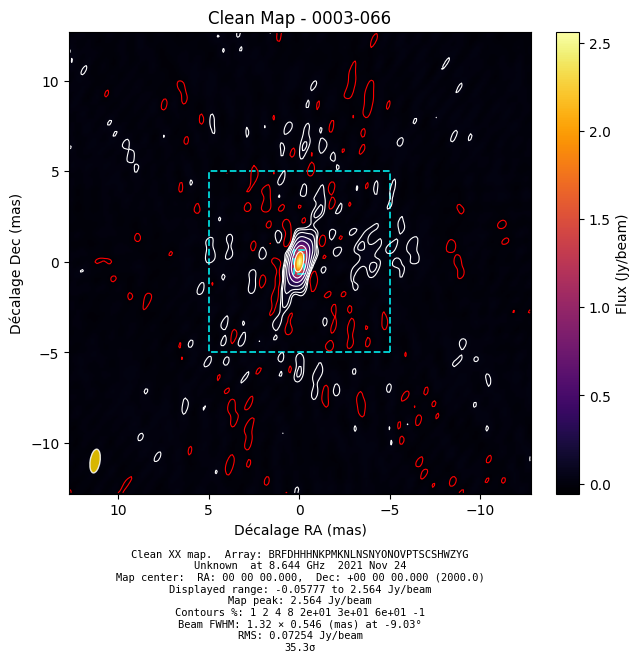

In [9]:
# Restauration: convolution du modèle avec le beam propre
session.imager.restore()
print("✓ restore(): modèle convolué avec le faisceau propre")

# Affichage de la Clean Map
session.vis.mapplot(
    title=f"Clean Map - {session.obs.source}",
    cmap="inferno",
    xlim=(-15, 15),
    ylim=(-15, 15),
)
plt.show()

# ## 8b. Clean Map avec composantes du modèle

Nombre de composantes dans le package: 26


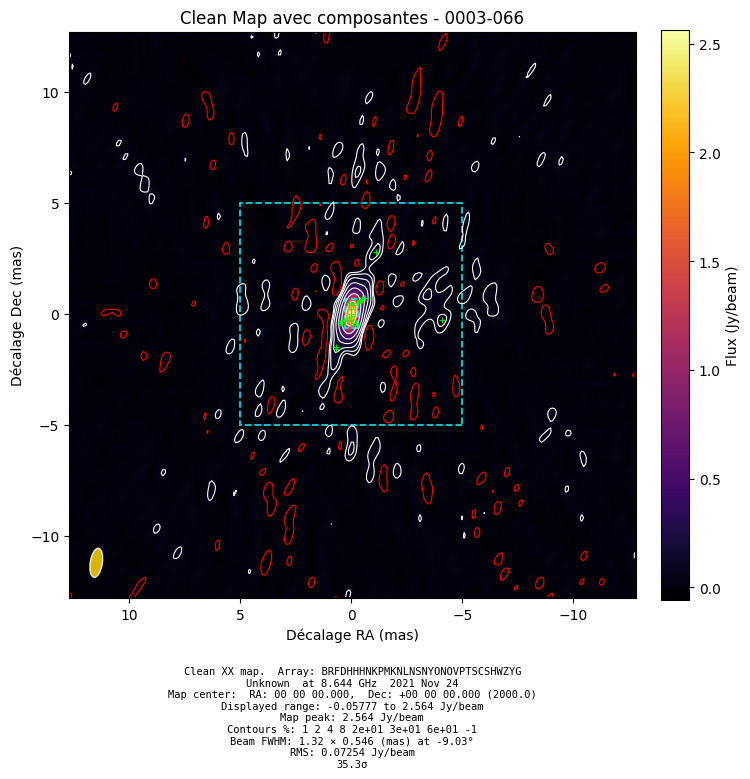

In [10]:
# Affichage de la Clean Map avec les composantes CLEAN superposées
# show_model=True affiche les composantes delta (+) et gaussiennes (ellipses)
# Note: Les contours ne sont affichés QUE sur les clean maps (pas sur dirty/residual)
# Voir difmap.c:3855: docont = mappar.docont && ((vlbmap->ncmp && domap) || ...)
clean_pkg = session.imager.get_map_package(CELL_SIZE_MAS)

print(f"Nombre de composantes dans le package: {len(clean_pkg.get('model_components', []))}")

session.vis.plot_clean_map(
    clean_pkg,
    title=f"Clean Map avec composantes - {session.obs.source}",
    cmap='inferno',
    show_model=True,  # Affiche les composantes du modèle
    contour_mode='log',
    contour_absmin=1.0,
    contour_absmax=100.0,
    contour_factor=2.0,
)
plt.show()

# Légende des composantes:
# - Symbole '+' vert : composante à flux positif
# - Symbole '+' rouge : composante à flux négatif
# - Ellipse blanche : composante gaussienne étendue à flux positif
# - Ellipse rouge : composante gaussienne à flux négatif

# ## 9. Residual Map (résidus non déconvolués)

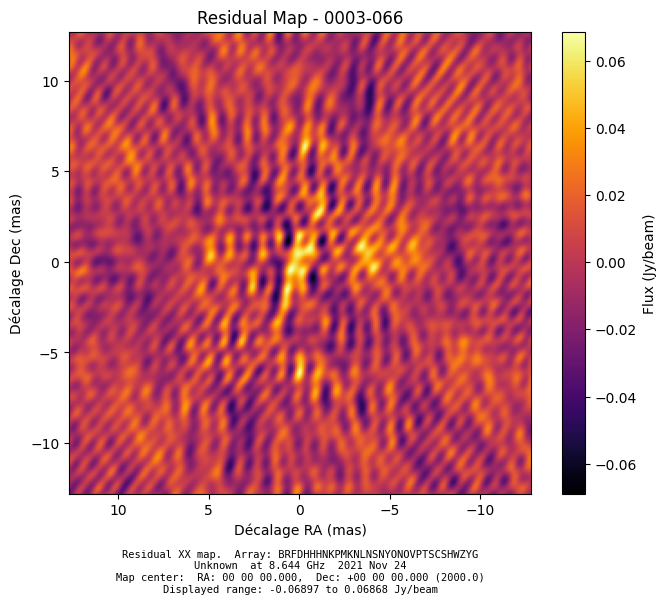

Résidu peak  : 68.972 mJy/beam
Résidu RMS   : 24.484 mJy/beam
Résidu SNR   : 2.8


In [11]:
# La Residual Map montre ce que CLEAN n'a pas pu déconvoluer

residual_pkg = session.imager.get_residual_package(CELL_SIZE_MAS)

# Affichage sans contours
# Important: ne pas forcer xlim/ylim plus grands que l'extent de l'image
# sinon ça crée une marge (cadre blanc) dans la figure.
session.vis.plot_image(
    residual_pkg,
    title=f"Residual Map - {session.obs.source}",
    figsize=(8, 6),
)
plt.show()

# Statistiques depuis les données résiduelles réelles (RMS zone centrale)
data_res = residual_pkg['data']
rms_res  = residual_pkg['info']['rms']
peak_res = float(np.nanmax(np.abs(data_res)))
print(f"Résidu peak  : {peak_res * 1000:.3f} mJy/beam")
print(f"Résidu RMS   : {rms_res  * 1000:.3f} mJy/beam")
if rms_res > 0:
    print(f"Résidu SNR   : {peak_res / rms_res:.1f}")
else:
    print("Résidu SNR   : N/A")

# ## 10. Composantes du modèle CLEAN

In [12]:
# Extraction des composantes delta détectées par CLEAN
components = session.imager.get_model_components()

print(f"Composantes détectées: {len(components)}")
print(f"\n{'#':>3} {'Flux (Jy)':>10} {'X (mas)':>10} {'Y (mas)':>10} {'Type':>10}")
print("─" * 50)

total_flux = 0
for i, c in enumerate(components[:15], 1):  # Affiche les 15 premières
    print(f"{i:>3} {c['flux']:>10.4f} {c['x']:>10.2f} {c['y']:>10.2f} {c['type']:>10}")
    total_flux += c['flux']

if len(components) > 15:
    print(f"... et {len(components)-15} autres")

print("─" * 50)
print(f"Flux total CLEAN: {total_flux:.4f} Jy")

Composantes détectées: 26

  #  Flux (Jy)    X (mas)    Y (mas)       Type
──────────────────────────────────────────────────
  1     1.9017       0.00       0.00      delta
  2     0.0648       0.00      -0.10      delta
  3     0.0587       0.00       0.20      delta
  4     0.0955       0.10      -0.20      delta
  5     0.0882      -0.10       0.40      delta
  6     0.0459       0.00      -0.30      delta
  7     0.0360       0.20      -0.30      delta
  8     0.0355      -0.30       0.50      delta
  9     0.1289      -0.20      -0.40      delta
 10     0.0847       0.30      -0.30      delta
 11     0.0573      -0.40       0.60      delta
 12     0.0920       0.10       0.40      delta
 13     0.0440      -0.50       0.60      delta
 14     0.0215       0.40      -0.30      delta
 15     0.0350       0.40      -0.40      delta
... et 11 autres
──────────────────────────────────────────────────
Flux total CLEAN: 2.7897 Jy


# ## 11. Pipeline complet en une ligne

clrmod: Cleared the established and tentative models.
Restored previously made model of latest selection.
Selecting polarization: RR,  channels: 1..4
Reading IF 1 channels: 1..1
Reading IF 2 channels: 2..2
Reading IF 3 channels: 3..3
Reading IF 4 channels: 4..4
clrmod: Cleared the established and tentative models.
Inverting map and beam 
Estimated beam: bmin=0.5457 mas, bmaj=1.323 mas, bpa=-9.027 degrees
Estimated noise=1.57154 mJy/beam.
Component: 050  -  total flux cleaned = 2.92667 Jy
Clean halted at first negative component
Total flux subtracted in 75 components = 3.16434 Jy
Clean residual min=-0.068972 max=0.068677 Jy/beam
Clean residual mean=0.000488 rms=0.014561 Jy/beam
Pipeline terminé!
  Dimensions: 256×256 pixels
  Beam: 1.323 × 0.546 mas, PA=-9.0°
Clean map  min=-0.057769  max=2.5643 Jy/beam


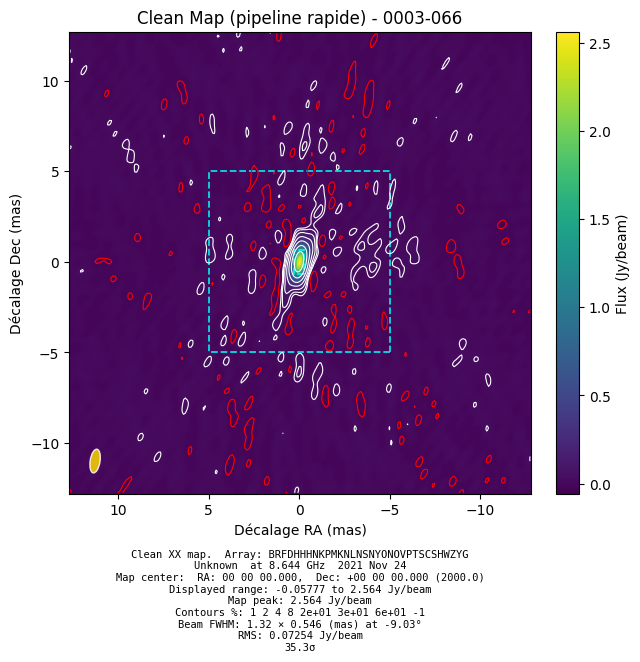

In [13]:
# ═══════════════════════════════════════════════════════════════════════════════
# MÉTHODE COMMODE: make_clean_map()
# ═══════════════════════════════════════════════════════════════════════════════

# Pour un pipeline rapide sans étapes intermédiaires:
# On réutilise la session existante (singleton - une seule session active à la fois)

# Pipeline complet: select → mapsize → invert → clean → restore
img = session.imager.make_clean_map(
    size=MAP_SIZE,
    cellsize=CELL_SIZE_MAS,
    niter=-300,      # arrêt au 1er négatif
    gain=0.1,
    cutoff=0.002,    # 2 mJy
    pol="RR"
)

print(f"Pipeline terminé!")
print(f"  Dimensions: {img['info']['nx']}×{img['info']['ny']} pixels")
print(f"  Beam: {img['info']['bmaj']:.3f} × {img['info']['bmin']:.3f} mas, PA={img['info']['bpa']:.1f}°")

# Affichage direct (sans contours car c'est géré par plot_clean_map)
session.vis.mapplot(
    title=f"Clean Map (pipeline rapide) - {session.obs.source}",
    cmap="viridis",
    xlim=(-12, 12),
    ylim=(-12, 12),
)
plt.show()

# ## 12. Auto-calibration (Selfcal)

Selfcal phase-only...
Adding 26 model components to the UV plane model.
The established model now contains 26 components and 3.16434 Jy

Correcting IF 1.
 A total of 1386 telescope corrections were flagged in sub-array 1.
 A total of 457 telescope corrections were flagged in sub-array 2.
 A total of 1861 telescope corrections were flagged in sub-array 3.
 A total of 697 telescope corrections were flagged in sub-array 4.
 A total of 399 telescope corrections were flagged in sub-array 5.

Correcting IF 2.
 A total of 1386 telescope corrections were flagged in sub-array 1.
 A total of 457 telescope corrections were flagged in sub-array 2.
 A total of 1861 telescope corrections were flagged in sub-array 3.
 A total of 697 telescope corrections were flagged in sub-array 4.
 A total of 399 telescope corrections were flagged in sub-array 5.

Correcting IF 3.
 A total of 1386 telescope corrections were flagged in sub-array 1.
 A total of 457 telescope corrections were flagged in sub-array 2.
 

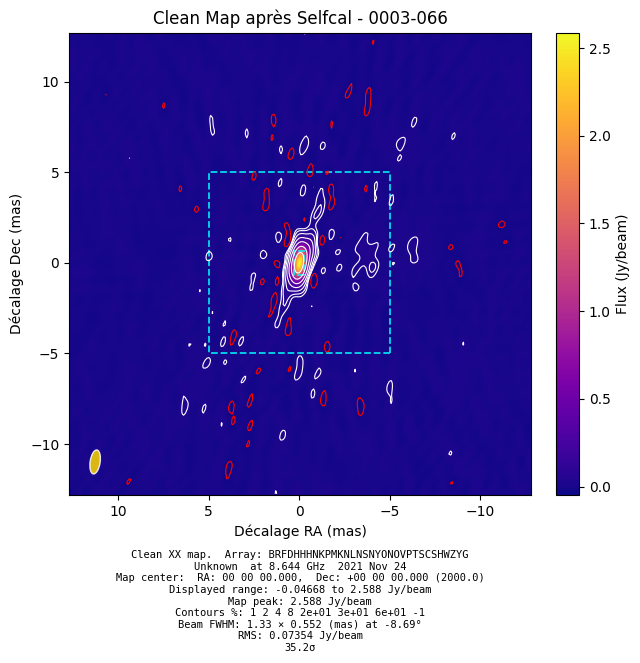

In [14]:
# ═══════════════════════════════════════════════════════════════════════════════
# AUTO-CALIBRATION AVEC LE MODÈLE CLEAN
# ═══════════════════════════════════════════════════════════════════════════════

# La selfcal utilise le modèle CLEAN pour corriger les erreurs de gain/phase

# 1. Selfcal phase-only (premier passage)
print("Selfcal phase-only...")
session.imager.selfcal(doamp=False, solint=0.0)  # solint=0 = par intégration

# 2. Recalculer la carte avec les gains corrigés
session.imager.clrmod()
session.imager.invert()
session.imager.clean(niter=-500, gain=0.05, cutoff=0.001)
session.imager.restore()

peak_after = session.imager.peak()
print(f"\nAprès selfcal phase:")
print(f"  Pic: {peak_after['flux']:.4f} Jy/beam")
print(f"  RMS: {peak_after['rms']*1000:.3f} mJy/beam")
print(f"  SNR: {peak_after['snr']:.1f}")

# Affichage
session.vis.mapplot(
    title=f"Clean Map après Selfcal - {session.obs.source}",
    cmap="plasma",
    xlim=(-10, 10),
    ylim=(-10, 10),
)
plt.show()

# ## 13. Comparaison Dirty vs Residual

clrmod: Cleared the established and tentative models.
Inverting map and beam 
Estimated beam: bmin=0.5521 mas, bmaj=1.335 mas, bpa=-8.686 degrees
Estimated noise=1.59669 mJy/beam.


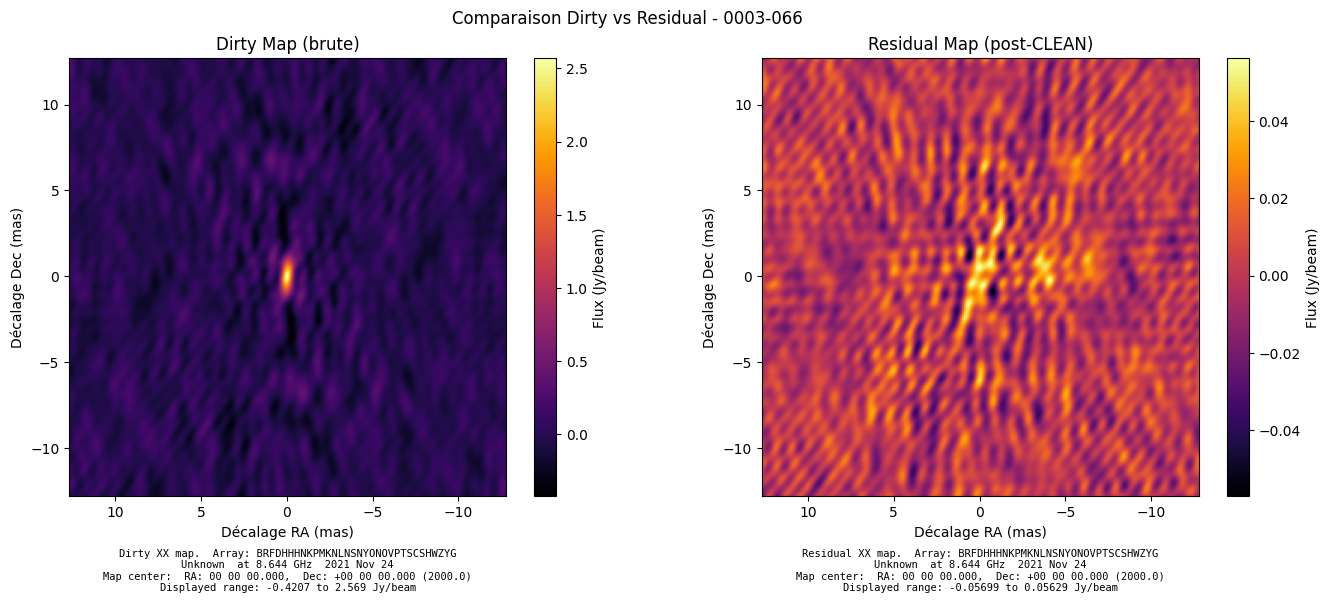

In [15]:
# ═══════════════════════════════════════════════════════════════════════════════
# COMPARAISON VISUELLE DIRTY vs RESIDUAL
# ═══════════════════════════════════════════════════════════════════════════════

# Sauvegarder la Residual Map actuelle
residual_img = session.imager.get_residual_package(CELL_SIZE_MAS)

# Recréer une Dirty Map pour comparaison (sans déconvolution)
session.imager.clrmod()
session.imager.invert()
dirty_img = session.imager.get_map_package(CELL_SIZE_MAS)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

session.vis.plot_image(
    dirty_img,
    ax=axes[0],
    title="Dirty Map (brute)",
    cmap='inferno',
    show=False,
)

session.vis.plot_image(
    residual_img,
    ax=axes[1],
    title="Residual Map (post-CLEAN)",
    cmap='inferno',
    show=False,
)

plt.suptitle(f"Comparaison Dirty vs Residual - {session.obs.source}", fontsize=12)
plt.show()

# ## 14. Nettoyage et libération des ressources